Libraries imported successfully.
Output folder created: visualizations_week2

Dataset loaded from: titanic_cleaned_final.csv

Dataset Shape: (891, 13)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'AgeGroup']

Data preparation completed.
Final dataset shape: (891, 13)

Creating Visualization 1...


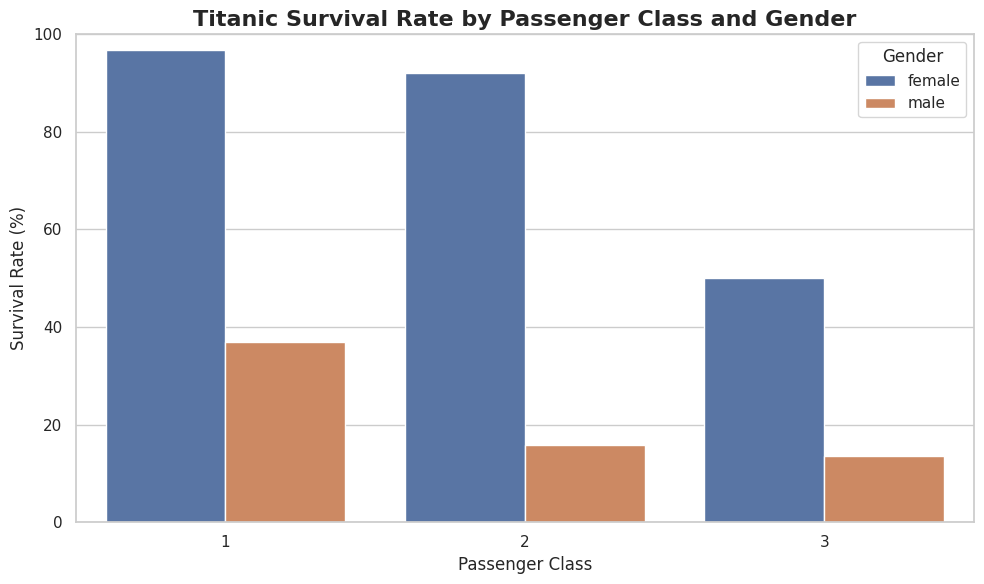


Creating Visualization 2...


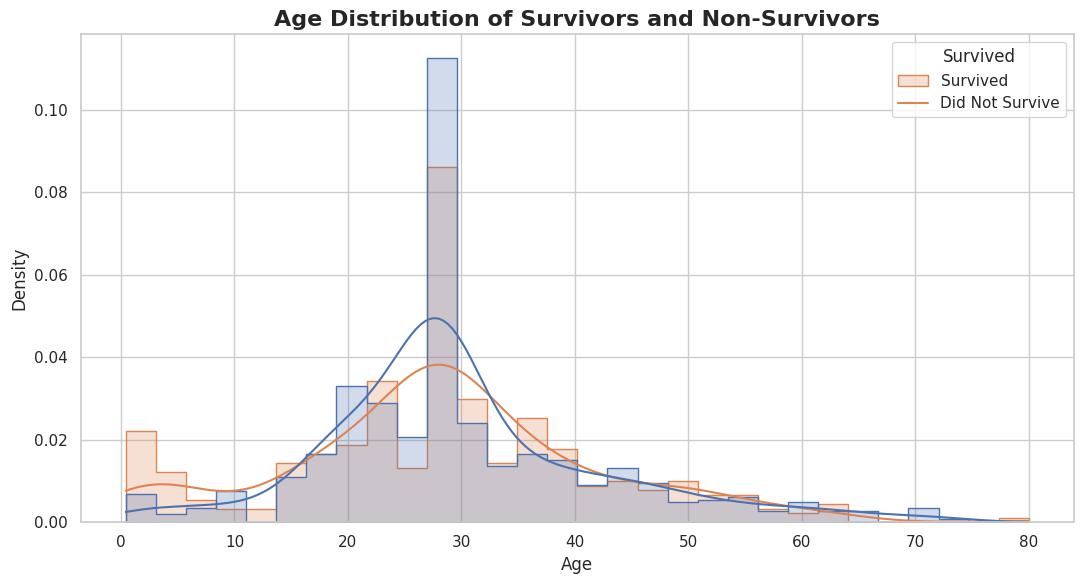


Creating Visualization 3...


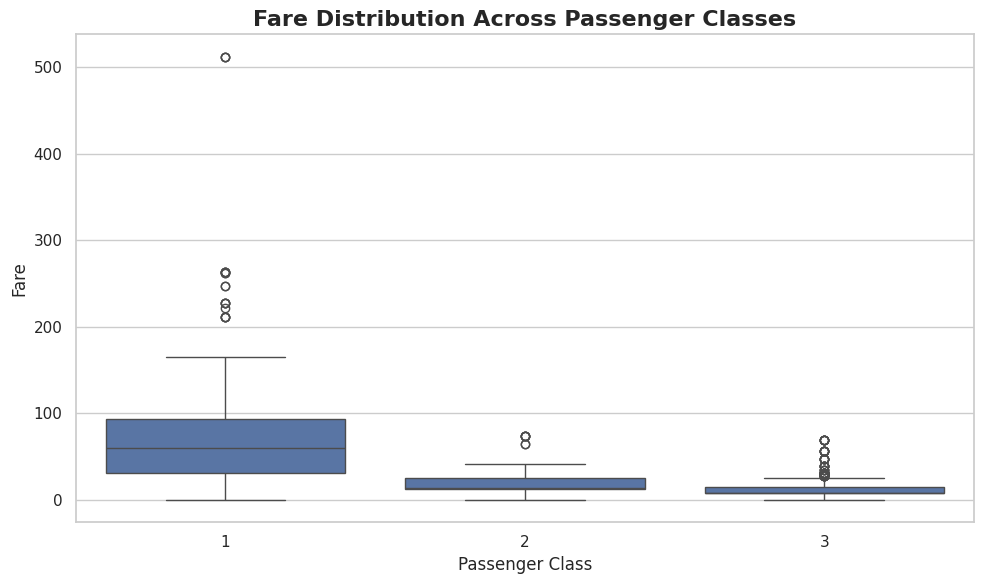


Creating Visualization 4...


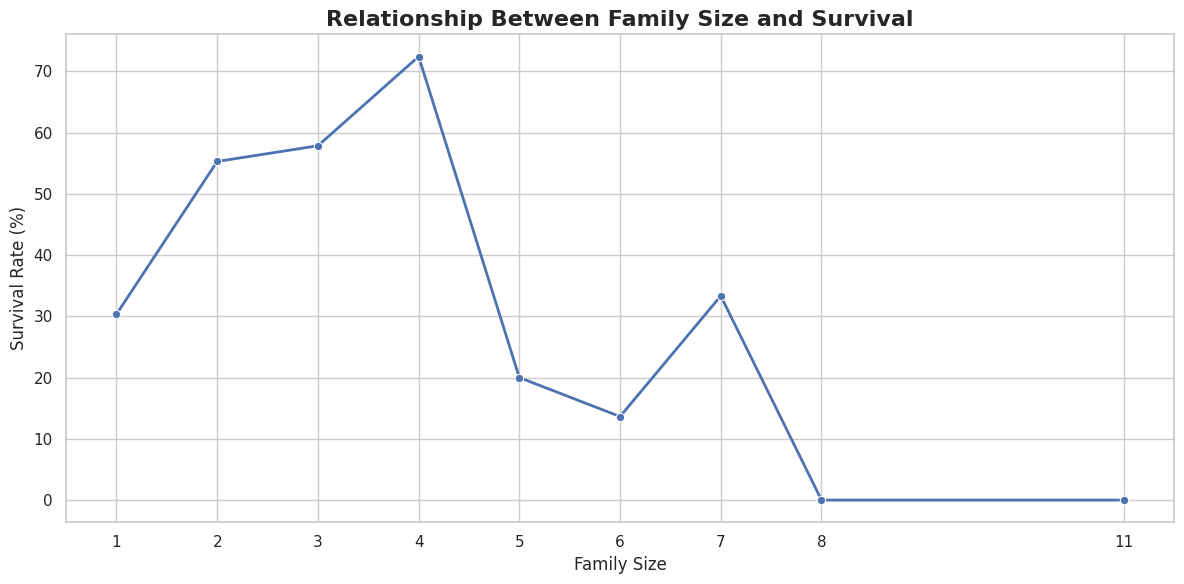


Creating Visualization 5...


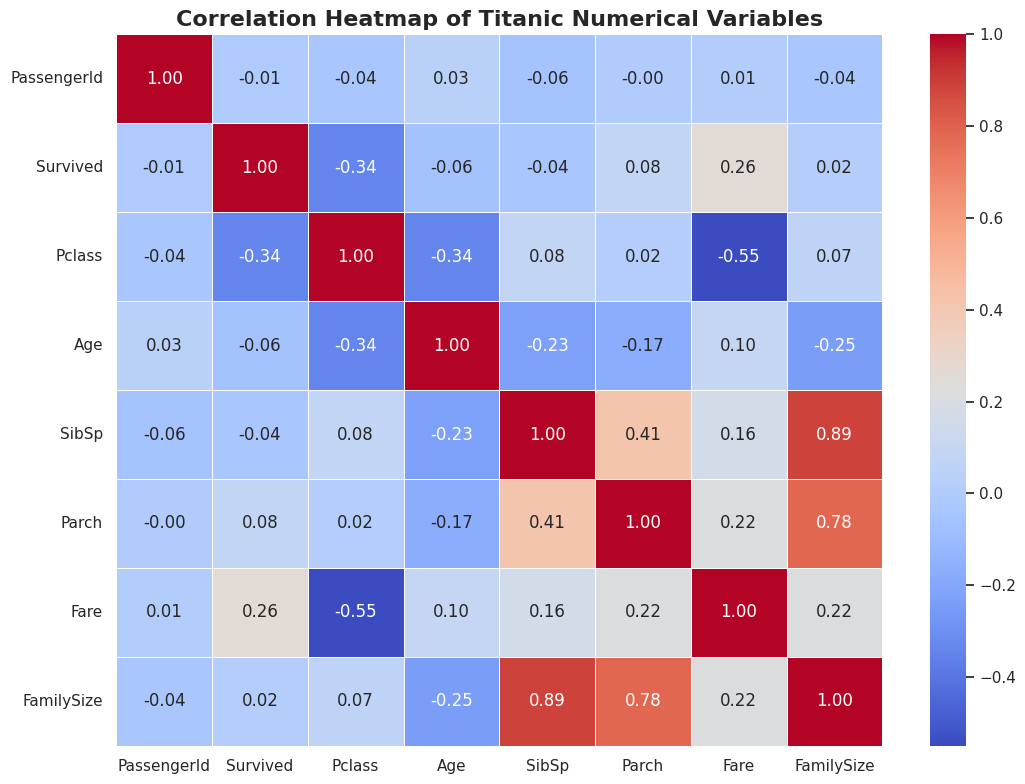


Creating Visualization 6...



Creating additional visualization...


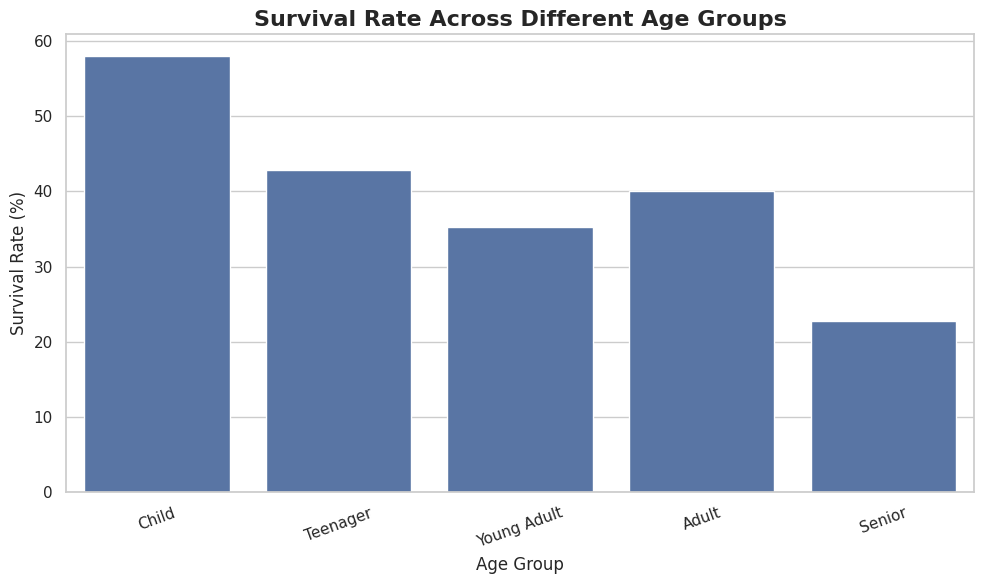


KEY ANALYTICAL INSIGHTS
1. Overall Survival Rate: 38.38% of passengers in the dataset survived.
2. Gender and Survival: Female survival rate was 74.20% while male survival rate was 18.89%.
3. Passenger Class: Class 1 had the highest survival rate (62.96%), while Class 3 had the lowest (24.24%).
4. Age Pattern: The average age of survivors was 28.29 years, compared with 30.03 years for non-survivors.
5. Family Size: Family size 4 showed the highest observed survival rate of 72.41%.
6. Fare Pattern: Survivors paid an average fare of 48.40, compared with 22.12 for non-survivors.

Insights saved to: visualizations_week2/week2_key_insights.txt

DATASET SUMMARY


,Metric,Value
0,Dataset Rows,891
1,Dataset Columns,15
2,Overall Survival Rate,38.38%
3,Average Age,29.36
4,Average Fare,32.20



GENERATED FILES
✓ 06_interactive_age_fare_survival.html
✓ week2_key_insights.txt
✓ 02_age_distribution_survival.png
✓ 07_survival_by_age_group.png
✓ 04_family_size_survival.png
✓ 03_fare_distribution_by_class.png
✓ 05_correlation_heatmap.png
✓ 01_survival_by_gender_and_class.png
✓ week2_summary.csv

ZIP file created successfully:
/content/week2_visualizations.zip

WEEK 2 ANALYSIS COMPLETED SUCCESSFULLY!


In [2]:
# ============================================================
# WEEK 2 - ADVANCED DATA VISUALIZATION AND STORYTELLING
# Titanic Dataset
# Name: Priya N
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from google.colab import files

# Set plotting style
sns.set_theme(style="whitegrid")

# Create folder for visualization outputs
output_folder = "visualizations_week2"
os.makedirs(output_folder, exist_ok=True)

print("Libraries imported successfully.")
print("Output folder created:", output_folder)


# ============================================================
# 2. LOAD DATASET
# ============================================================

# Try to use the cleaned Titanic dataset from Week 1
file_path = "titanic_cleaned_final.csv"

if os.path.exists(file_path):

    df = pd.read_csv(file_path)
    print("\nDataset loaded from:", file_path)

else:

    print("\nWeek 1 CSV not found.")
    print("Please upload your Titanic CSV file.")

    uploaded = files.upload()

    uploaded_file = list(uploaded.keys())[0]
    df = pd.read_csv(uploaded_file)

    print("\nDataset loaded from:", uploaded_file)


# ============================================================
# 3. BASIC DATA PREPARATION
# ============================================================

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

# Standardize column names
df.columns = [col.strip() for col in df.columns]

# ------------------------------------------------------------
# Rename columns if necessary
# ------------------------------------------------------------

column_mapping = {}

for col in df.columns:

    lower_col = col.lower()

    if lower_col == "pclass":
        column_mapping[col] = "Pclass"

    elif lower_col == "sex":
        column_mapping[col] = "Sex"

    elif lower_col == "age":
        column_mapping[col] = "Age"

    elif lower_col == "fare":
        column_mapping[col] = "Fare"

    elif lower_col == "survived":
        column_mapping[col] = "Survived"

    elif lower_col == "sibsp":
        column_mapping[col] = "SibSp"

    elif lower_col == "parch":
        column_mapping[col] = "Parch"

    elif lower_col == "embarked":
        column_mapping[col] = "Embarked"

    elif lower_col == "name":
        column_mapping[col] = "Name"

    elif lower_col == "passengerid":
        column_mapping[col] = "PassengerId"

df.rename(columns=column_mapping, inplace=True)


# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

if "Age" in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    df["Age"] = df["Age"].fillna(df["Age"].median())

if "Fare" in df.columns:
    df["Fare"] = pd.to_numeric(df["Fare"], errors="coerce")
    df["Fare"] = df["Fare"].fillna(df["Fare"].median())

if "Embarked" in df.columns:
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

if "Sex" in df.columns:
    df["Sex"] = df["Sex"].fillna(df["Sex"].mode()[0])

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("\nData preparation completed.")
print("Final dataset shape:", df.shape)


# ============================================================
# 5. CREATE AGE GROUPS
# ============================================================

if "Age" in df.columns:

    df["Age_Group"] = pd.cut(
        df["Age"],
        bins=[0, 12, 18, 35, 60, 100],
        labels=[
            "Child",
            "Teenager",
            "Young Adult",
            "Adult",
            "Senior"
        ],
        include_lowest=True
    )


# ============================================================
# 6. CREATE FAMILY SIZE
# ============================================================

if "SibSp" in df.columns and "Parch" in df.columns:

    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    df["Family_Category"] = pd.cut(
        df["FamilySize"],
        bins=[0, 1, 4, 7, 20],
        labels=[
            "Alone",
            "Small Family",
            "Medium Family",
            "Large Family"
        ]
    )


# ============================================================
# VISUALIZATION 1
# SURVIVAL RATE BY GENDER AND PASSENGER CLASS
# ============================================================

print("\nCreating Visualization 1...")

if all(col in df.columns for col in ["Sex", "Pclass", "Survived"]):

    survival_gender_class = (
        df.groupby(["Pclass", "Sex"])["Survived"]
        .mean()
        .reset_index()
    )

    survival_gender_class["Survival Rate (%)"] = (
        survival_gender_class["Survived"] * 100
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=survival_gender_class,
        x="Pclass",
        y="Survival Rate (%)",
        hue="Sex"
    )

    plt.title(
        "Titanic Survival Rate by Passenger Class and Gender",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Passenger Class")
    plt.ylabel("Survival Rate (%)")
    plt.ylim(0, 100)
    plt.legend(title="Gender")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_folder,
            "01_survival_by_gender_and_class.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# VISUALIZATION 2
# AGE DISTRIBUTION BY SURVIVAL
# ============================================================

print("\nCreating Visualization 2...")

if all(col in df.columns for col in ["Age", "Survived"]):

    plt.figure(figsize=(11, 6))

    sns.histplot(
        data=df,
        x="Age",
        hue="Survived",
        bins=30,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(
        "Age Distribution of Survivors and Non-Survivors",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Density")

    plt.legend(
        title="Survived",
        labels=["Survived", "Did Not Survive"]
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_folder,
            "02_age_distribution_survival.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# VISUALIZATION 3
# FARE DISTRIBUTION BY PASSENGER CLASS
# ============================================================

print("\nCreating Visualization 3...")

if all(col in df.columns for col in ["Fare", "Pclass"]):

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x="Pclass",
        y="Fare"
    )

    plt.title(
        "Fare Distribution Across Passenger Classes",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Passenger Class")
    plt.ylabel("Fare")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_folder,
            "03_fare_distribution_by_class.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# VISUALIZATION 4
# FAMILY SIZE VS SURVIVAL
# ============================================================

print("\nCreating Visualization 4...")

if all(col in df.columns for col in ["FamilySize", "Survived"]):

    family_survival = (
        df.groupby("FamilySize")["Survived"]
        .mean()
        .reset_index()
    )

    family_survival["Survival Rate (%)"] = (
        family_survival["Survived"] * 100
    )

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=family_survival,
        x="FamilySize",
        y="Survival Rate (%)",
        marker="o",
        linewidth=2
    )

    plt.title(
        "Relationship Between Family Size and Survival",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Family Size")
    plt.ylabel("Survival Rate (%)")

    plt.xticks(
        sorted(df["FamilySize"].unique())
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_folder,
            "04_family_size_survival.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# VISUALIZATION 5
# CORRELATION HEATMAP
# ============================================================

print("\nCreating Visualization 5...")

numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Titanic Numerical Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        output_folder,
        "05_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# VISUALIZATION 6
# INTERACTIVE PLOTLY VISUALIZATION
# SURVIVAL BY AGE, FARE AND CLASS
# ============================================================

print("\nCreating Visualization 6...")

plotly_columns = [
    "Age",
    "Fare",
    "Pclass",
    "Survived"
]

if all(col in df.columns for col in plotly_columns):

    plot_df = df.copy()

    plot_df["Survival Status"] = plot_df["Survived"].map({
        0: "Did Not Survive",
        1: "Survived"
    })

    fig = px.scatter(
        plot_df,
        x="Age",
        y="Fare",
        color="Survival Status",
        size="Pclass",
        hover_data=[
            "Pclass",
            "Sex" if "Sex" in plot_df.columns else "Age"
        ],
        title="Titanic Survival Patterns: Age vs Fare",
        labels={
            "Age": "Passenger Age",
            "Fare": "Ticket Fare"
        }
    )

    fig.update_layout(
        title_font_size=20,
        xaxis_title="Passenger Age",
        yaxis_title="Ticket Fare"
    )

    fig.show()

    fig.write_html(
        os.path.join(
            output_folder,
            "06_interactive_age_fare_survival.html"
        )
    )


# ============================================================
# 7. ADDITIONAL VISUALIZATION
# SURVIVAL BY AGE GROUP
# ============================================================

print("\nCreating additional visualization...")

if all(col in df.columns for col in ["Age_Group", "Survived"]):

    age_survival = (
        df.groupby("Age_Group", observed=False)["Survived"]
        .mean()
        .reset_index()
    )

    age_survival["Survival Rate (%)"] = (
        age_survival["Survived"] * 100
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=age_survival,
        x="Age_Group",
        y="Survival Rate (%)"
    )

    plt.title(
        "Survival Rate Across Different Age Groups",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Survival Rate (%)")
    plt.xticks(rotation=20)

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            output_folder,
            "07_survival_by_age_group.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 8. CALCULATE IMPORTANT INSIGHTS
# ============================================================

print("\n" + "=" * 60)
print("KEY ANALYTICAL INSIGHTS")
print("=" * 60)


insights = []


# Overall survival
if "Survived" in df.columns:

    overall_survival = df["Survived"].mean() * 100

    insight = (
        f"1. Overall Survival Rate: "
        f"{overall_survival:.2f}% of passengers in the dataset survived."
    )

    print(insight)
    insights.append(insight)


# Gender survival
if all(col in df.columns for col in ["Sex", "Survived"]):

    gender_survival = (
        df.groupby("Sex")["Survived"]
        .mean()
        .mul(100)
    )

    insight = (
        f"2. Gender and Survival: "
        f"Female survival rate was {gender_survival.get('female', 0):.2f}% "
        f"while male survival rate was {gender_survival.get('male', 0):.2f}%."
    )

    print(insight)
    insights.append(insight)


# Class survival
if all(col in df.columns for col in ["Pclass", "Survived"]):

    class_survival = (
        df.groupby("Pclass")["Survived"]
        .mean()
        .mul(100)
    )

    highest_class = class_survival.idxmax()
    lowest_class = class_survival.idxmin()

    insight = (
        f"3. Passenger Class: "
        f"Class {highest_class} had the highest survival rate "
        f"({class_survival[highest_class]:.2f}%), while "
        f"Class {lowest_class} had the lowest "
        f"({class_survival[lowest_class]:.2f}%)."
    )

    print(insight)
    insights.append(insight)


# Age
if all(col in df.columns for col in ["Age", "Survived"]):

    survivor_age = df.loc[
        df["Survived"] == 1,
        "Age"
    ].mean()

    non_survivor_age = df.loc[
        df["Survived"] == 0,
        "Age"
    ].mean()

    insight = (
        f"4. Age Pattern: "
        f"The average age of survivors was {survivor_age:.2f} years, "
        f"compared with {non_survivor_age:.2f} years for non-survivors."
    )

    print(insight)
    insights.append(insight)


# Family size
if all(col in df.columns for col in ["FamilySize", "Survived"]):

    family_survival_rates = (
        df.groupby("FamilySize")["Survived"]
        .mean()
    )

    best_family_size = family_survival_rates.idxmax()
    best_family_rate = family_survival_rates.max() * 100

    insight = (
        f"5. Family Size: "
        f"Family size {best_family_size} showed the highest observed "
        f"survival rate of {best_family_rate:.2f}%."
    )

    print(insight)
    insights.append(insight)


# Fare
if all(col in df.columns for col in ["Fare", "Survived"]):

    survivor_fare = df.loc[
        df["Survived"] == 1,
        "Fare"
    ].mean()

    non_survivor_fare = df.loc[
        df["Survived"] == 0,
        "Fare"
    ].mean()

    insight = (
        f"6. Fare Pattern: "
        f"Survivors paid an average fare of {survivor_fare:.2f}, "
        f"compared with {non_survivor_fare:.2f} for non-survivors."
    )

    print(insight)
    insights.append(insight)


# ============================================================
# 9. SAVE INSIGHTS TO TEXT FILE
# ============================================================

insight_file = os.path.join(
    output_folder,
    "week2_key_insights.txt"
)

with open(insight_file, "w") as f:

    f.write("WEEK 2 - TITANIC DATA VISUALIZATION\n")
    f.write("Name: Priya N\n")
    f.write("=" * 60 + "\n\n")

    for insight in insights:
        f.write(insight + "\n\n")

print("\nInsights saved to:", insight_file)


# ============================================================
# 10. CREATE SUMMARY TABLE
# ============================================================

summary_data = {
    "Metric": [
        "Dataset Rows",
        "Dataset Columns",
        "Overall Survival Rate",
        "Average Age",
        "Average Fare"
    ],
    "Value": [
        len(df),
        len(df.columns),
        f"{df['Survived'].mean() * 100:.2f}%"
        if "Survived" in df.columns else "N/A",
        f"{df['Age'].mean():.2f}"
        if "Age" in df.columns else "N/A",
        f"{df['Fare'].mean():.2f}"
        if "Fare" in df.columns else "N/A"
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

display(summary_df)


# ============================================================
# 11. SAVE SUMMARY CSV
# ============================================================

summary_df.to_csv(
    os.path.join(
        output_folder,
        "week2_summary.csv"
    ),
    index=False
)


# ============================================================
# 12. LIST ALL GENERATED FILES
# ============================================================

print("\n" + "=" * 60)
print("GENERATED FILES")
print("=" * 60)

for filename in os.listdir(output_folder):
    print("✓", filename)


# ============================================================
# 13. CREATE ZIP FILE FOR EASY GITHUB UPLOAD
# ============================================================

import shutil

zip_file = shutil.make_archive(
    "week2_visualizations",
    "zip",
    output_folder
)

print("\nZIP file created successfully:")
print(zip_file)

print("\n" + "=" * 60)
print("WEEK 2 ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 60)

